In [13]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\Brent_Crude_Oil_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

         date       open       high        low      close  volume
0  2007-07-30  75.849998  76.529999  75.440002  75.739998    2575
1  2007-07-31  75.699997  77.169998  75.669998  77.050003    3513
2  2007-08-01  77.000000  77.059998  74.860001  75.349998    3930
3  2007-08-02  75.220001  76.209999  74.269997  75.760002    6180
4  2007-08-03  75.389999  76.000000  74.529999  74.750000    4387


In [15]:
print(df.columns)


Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [16]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4196 entries, 0 to 4195
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    4196 non-null   object 
 1   open    4196 non-null   float64
 2   high    4196 non-null   float64
 3   low     4196 non-null   float64
 4   close   4196 non-null   float64
 5   volume  4196 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 196.8+ KB
None


In [17]:
print(df.isnull().sum())

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [18]:
# Đảm bảo cột ngày là định dạng datetime
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)             # Đặt 'date' làm index
df.sort_index(inplace=True)     

# Trích xuất thêm thông tin từ ngày
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

In [19]:
for col in ['open', 'high', 'low', 'close']:
    df[col] = df[col].apply(lambda x: x if x > 0 else df.interpolate(method='linear', inplace=True)())  # Thay bằng giá trị trung bình của cột


In [20]:
# Nếu lỡ đánh date thành index, bỏ index cho cột date bằng cách sau

df.reset_index(inplace=True)           
df.sort_index(inplace=True)                   


In [21]:
import matplotlib.pyplot as plt


features = ['open', 'high', 'low', 'volume', 'year', 'month', 'day']
target = 'close'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo mô hình
model = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.1,  # 0.05
    loss_function='RMSE',
    verbose=0
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tính các độ lỗi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📌- Mean Absolute Error (MAE): {mae:.4f}")
print(f"📌- Mean Squared Error (MSE): {mse:.4f}")
print(f"📌- Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📌- R-squared (R²): {r2:.4f}")


📌- Mean Absolute Error (MAE): 0.6086
📌- Mean Squared Error (MSE): 0.8024
📌- Root Mean Squared Error (RMSE): 0.8958
📌- R-squared (R²): 0.9986


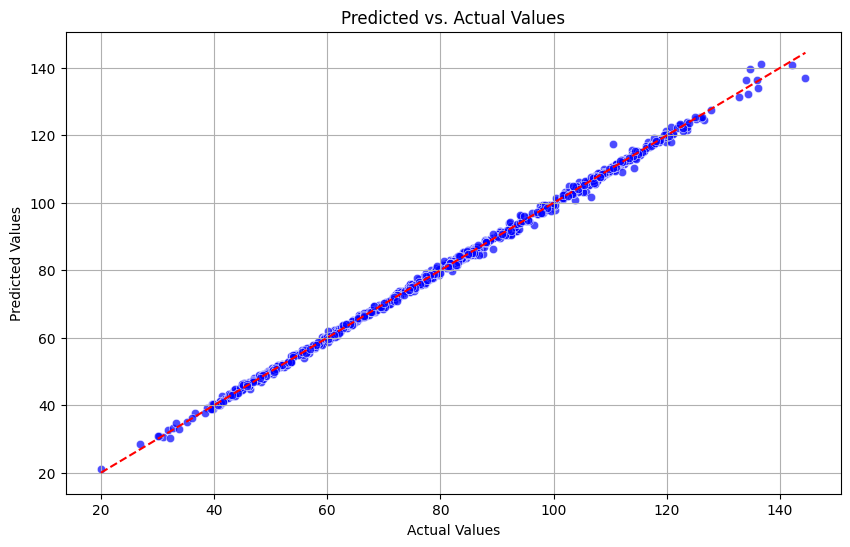

In [23]:
# Visualize Predicted vs. Actual Values
import seaborn as sns  # For advanced visualizations
# Create a scatter plot to compare predicted values against actual values
plt.figure(figsize=(10, 6))  # Set the figure size
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='blue')  # Scatter plot
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Line y=x
plt.title("Predicted vs. Actual Values")  # Title of the plot
plt.xlabel("Actual Values")  # Label for x-axis
plt.ylabel("Predicted Values")  # Label for y-axis
plt.grid(True)  # Add grid for better readability
plt.show()  # Display the plot

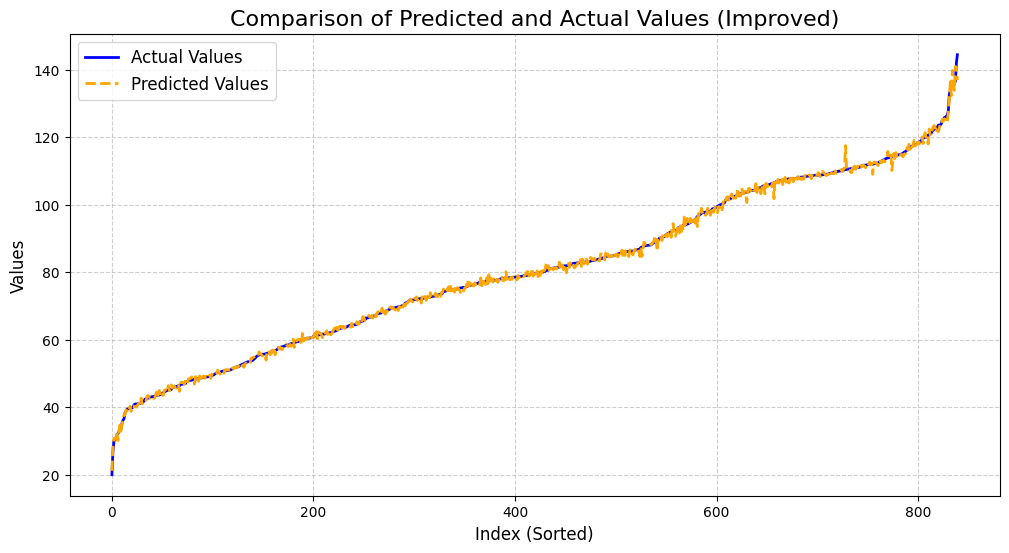

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Sắp xếp dữ liệu theo giá trị thực (nếu cần)
sorted_indices = y_test.argsort()
y_test_sorted = y_test.iloc[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))  # Kích thước biểu đồ
plt.plot(y_test_sorted.values, label='Actual Values', color='blue', linestyle='-', linewidth=2)  # Giá trị thực
plt.plot(y_pred_sorted, label='Predicted Values', color='orange', linestyle='--', linewidth=2)  # Giá trị dự đoán

# Thêm tiêu đề và nhãn
plt.title("Comparison of Predicted and Actual Values (Improved)", fontsize=16)
plt.xlabel("Index (Sorted)", fontsize=12)
plt.ylabel("Values", fontsize=12)

# Thêm chú thích và lưới
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị biểu đồ
plt.show()

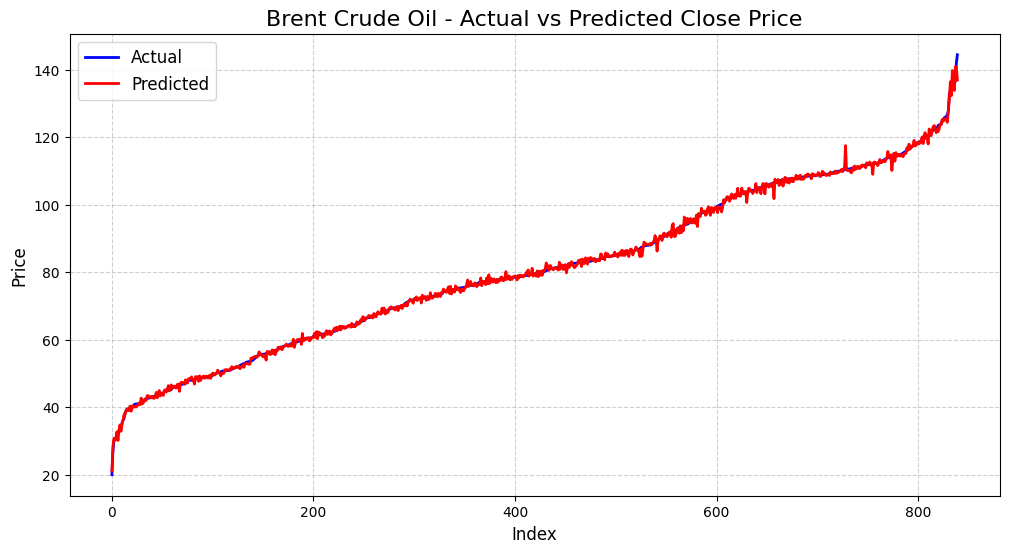

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Sắp xếp dữ liệu theo giá trị thực (nếu cần)
sorted_indices = y_test.argsort()
y_test_sorted = y_test.iloc[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))  # Kích thước biểu đồ
plt.plot(y_test_sorted.values, label='Actual', color='blue', linewidth=2)  # Giá trị thực
plt.plot(y_pred_sorted, label='Predicted', color='red', linewidth=2)  # Giá trị dự đoán

# Thêm tiêu đề và nhãn
plt.title("Brent Crude Oil - Actual vs Predicted Close Price", fontsize=16)
plt.xlabel("Index", fontsize=12)
plt.ylabel("Price", fontsize=12)

# Thêm chú thích và lưới
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị biểu đồ
plt.show()